# Fase 2 — Comprensión de los Datos
## Sección 04: Análisis Geográfico – Precios por Ciudad

**Notebook:** `notebooks/04_EDA_analisis_geografico.ipynb`  
**Responsable:** Sofía | **Apoyo:** Steve  
**Objetivo:** Comparar el precio mediano de vivienda y el precio por m² entre las 12 ciudades focales,
identificar el rango intercuartílico de cada mercado y evidenciar la polarización de precios entre ciudades.

## Configuración inicial

In [1]:
from config import *
import unicodedata
print(f'Raw : {RAW}')
print(f'Proc: {PROC}')
print(f'Figs: {FIGS}')


Raw : ..\data\raw
Proc: ..\data\processed
Figs: ..\docs\figures


## Carga y estandarización de datos

Se cargan las cuatro fuentes con columna de ciudad y precio (A1, A2, A5, A7).
Los nombres de ciudad se mapean a los 12 canónicos del proyecto.
Los precios se normalizan a COP completo y se filtra el rango $50 M – $5 000 M COP
(descarta valores en USD sin convertir y errores de escala; la conversión TRM año a año
se realizará en Fase 3).

In [6]:
CIUDADES_FOCALES = {
    'bogota': 'Bogotá', 'bogotá': 'Bogotá', 'santa fe de bogota': 'Bogotá',
    'bogota d.c': 'Bogotá', 'bogota d.c.': 'Bogotá', 'bogota dc': 'Bogotá',
    'medellin': 'Medellín', 'medellín': 'Medellín', 'medelln': 'Medellín',
    'cali': 'Cali', 'santiago de cali': 'Cali',
    'barranquilla': 'Barranquilla',
    'bucaramanga': 'Bucaramanga',
    'cartagena': 'Cartagena', 'cartagena de indias': 'Cartagena',
    'pereira': 'Pereira',
    'cucuta': 'Cúcuta', 'cúcuta': 'Cúcuta', 'san jose de cucuta': 'Cúcuta',
    'manizales': 'Manizales',
    'ibague': 'Ibagué', 'ibagué': 'Ibagué',
    'santa marta': 'Santa Marta',
    'villavicencio': 'Villavicencio',
}

def normalizar(s):
    if pd.isna(s):
        return ''
    t = unicodedata.normalize('NFKD', str(s).lower().strip())
    return t.encode('ascii', errors='ignore').decode('utf-8')

# ── A1: Properati Colombia ──────────────────────────────────────
print('Cargando A1 (Properati)...')

A1 = pd.read_csv(
    os.path.join(RAW, 'A1_colombia_housing_properties.csv'),
    encoding='utf-8-sig',
    low_memory=False
)

A1.columns = A1.columns.str.strip()

print(f"A1 cargado: {A1.shape[0]:,} filas x {A1.shape[1]} columnas")

# Tu archivo NO tiene l1, así que se elimina ese filtro
A1['ciudad'] = A1['l3'].apply(normalizar).map(CIUDADES_FOCALES)
A1['precio'] = A1['price']
A1['area'] = np.nan
A1['fuente'] = 'A1'

# ── A2: FincaRaiz Colombia ──────────────────────────────────────
print('Cargando A2 (FincaRaiz)...')

A2 = pd.read_csv(
    os.path.join(RAW, 'A2_fincaraiz_colombia.csv'),
    encoding='utf-8-sig',
    low_memory=False
)

A2.columns = A2.columns.str.strip()

A2['ciudad'] = A2['Ciudad'].apply(normalizar).map(CIUDADES_FOCALES)
A2['precio'] = A2['Precio'] * 1_000_000
A2['area'] = A2['Area Construida']
A2['fuente'] = 'A2'

# ── A5: Medellín Properties ─────────────────────────────────────
print('Cargando A5 (Medellín)...')

A5 = pd.read_csv(
    os.path.join(RAW, 'A5_medellin_properties_2023.csv'),
    encoding='utf-8-sig',
    low_memory=False
)

A5.columns = A5.columns.str.strip()

A5['ciudad'] = 'Medellín'
A5['precio'] = A5['price']
A5['area'] = A5['area']
A5['fuente'] = 'A5'

# ── A7: Villavicencio ───────────────────────────────────────────
print('Cargando A7 (Villavicencio)...')

A7 = pd.read_csv(
    os.path.join(RAW, 'A7_fincaraiz_villavicencio_scraping.csv'),
    encoding='utf-8-sig',
    low_memory=False
)

A7.columns = A7.columns.str.strip()

A7['ciudad'] = 'Villavicencio'
A7['precio'] = A7['precio_cop']
A7['area'] = A7['area_m2']
A7['fuente'] = 'A7'

# ── Consolidación ───────────────────────────────────────────────
COLS = ['ciudad', 'precio', 'area', 'fuente']

df_raw = pd.concat(
    [A1[COLS], A2[COLS], A5[COLS], A7[COLS]],
    ignore_index=True
)

df_raw = df_raw[
    df_raw['ciudad'].notna() &
    df_raw['precio'].notna()
]

# Filtro de precios
P_MIN = 50_000_000
P_MAX = 5_000_000_000

df = df_raw[
    (df_raw['precio'] >= P_MIN) &
    (df_raw['precio'] <= P_MAX)
].copy()

print(f"\nTotal antes del filtro de precio : {len(df_raw):>10,}")
print(f"Total después ($50M – $5.000M)  : {len(df):>10,}")
print(f"Ciudades cubiertas              : {df['ciudad'].nunique()}")
print("\nCiudades encontradas:")
print(sorted(df['ciudad'].dropna().unique()))

Cargando A1 (Properati)...
A1 cargado: 997,623 filas x 17 columnas
Cargando A2 (FincaRaiz)...
Cargando A5 (Medellín)...
Cargando A7 (Villavicencio)...

Total antes del filtro de precio :    868,507
Total después ($50M – $5.000M)  :    410,752
Ciudades cubiertas              : 12

Ciudades encontradas:
['Barranquilla', 'Bogotá', 'Bucaramanga', 'Cali', 'Cartagena', 'Cúcuta', 'Ibagué', 'Manizales', 'Medellín', 'Pereira', 'Santa Marta', 'Villavicencio']


In [7]:
# Cobertura por ciudad
cobertura = df.groupby('ciudad').agg(
    registros=('precio', 'count'),
    fuentes=('fuente', lambda x: ', '.join(sorted(x.unique())))
).sort_values('registros', ascending=False)
cobertura['%'] = (cobertura['registros'] / len(df) * 100).round(1)
display(cobertura)


,registros,fuentes,%
ciudad,,,
Medellín,128877,"A1, A5",31.4
Bogotá,98547,A1,24.0
Cali,58886,A1,14.3
Barranquilla,41046,A1,10.0
Manizales,26129,A1,6.4
Bucaramanga,13622,A1,3.3
Cúcuta,12698,A1,3.1
Pereira,12009,A1,2.9
Cartagena,6820,A1,1.7


**Conclusión de carga:**  
- Bogotá concentra la mayor parte del volumen (A1 + A2 + A3 + A6) y tiene la cobertura temporal más amplia.  
- Medellín cuenta con tres fuentes independientes (A1, A5), lo que permite validación cruzada.  
- Villavicencio depende casi exclusivamente del scraping A7 (~1 000 registros); se mantiene en el análisis pero con advertencia de cobertura.  
- El filtro $50 M–$5 000 M descarta precios en USD sin convertir de A1 (los precios en USD —p.ej. US$2 500— quedan por debajo del umbral). La conversión TRM se hará en Fase 3.

## Precio mediano por ciudad

In [8]:
# Estadísticas por ciudad: mediana, Q1, Q3, n
city_stats = (
    df.groupby('ciudad')['precio']
    .agg(
        mediana='median',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        n='count'
    )
    .reset_index()
    .sort_values('mediana', ascending=False)
)

mediana_nac = df['precio'].median()
print(f'Mediana nacional: ${mediana_nac / 1e6:,.0f} M COP')
print()

hdr = f'{"Ciudad":<16} {"Mediana":>10}  {"Q1":>10}  {"Q3":>10}  {"N":>8}'
print(hdr)
print('-' * len(hdr))
for _, r in city_stats.iterrows():
    print(f'  {r["ciudad"]:<14} ${r["mediana"]/1e6:>8.0f}M  ${r["Q1"]/1e6:>8.0f}M  ${r["Q3"]/1e6:>8.0f}M  {int(r["n"]):>8,}')


Mediana nacional: $355 M COP

Ciudad              Mediana          Q1          Q3         N
-------------------------------------------------------------
  Bogotá         $     520M  $     300M  $     950M    98,547
  Cartagena      $     490M  $     253M  $     800M     6,820
  Medellín       $     350M  $     250M  $     600M   128,877
  Barranquilla   $     340M  $     225M  $     584M    41,046
  Cali           $     330M  $     195M  $     590M    58,886
  Pereira        $     320M  $     195M  $     680M    12,009
  Santa Marta    $     300M  $     190M  $     565M     2,664
  Cúcuta         $     255M  $     160M  $     450M    12,698
  Manizales      $     251M  $     180M  $     390M    26,129
  Bucaramanga    $     250M  $     180M  $     380M    13,622
  Ibagué         $     240M  $     160M  $     430M     4,132
  Villavicencio  $     210M  $     135M  $     360M     5,322


Grafico guardado en: precio_mediano_ciudad.png


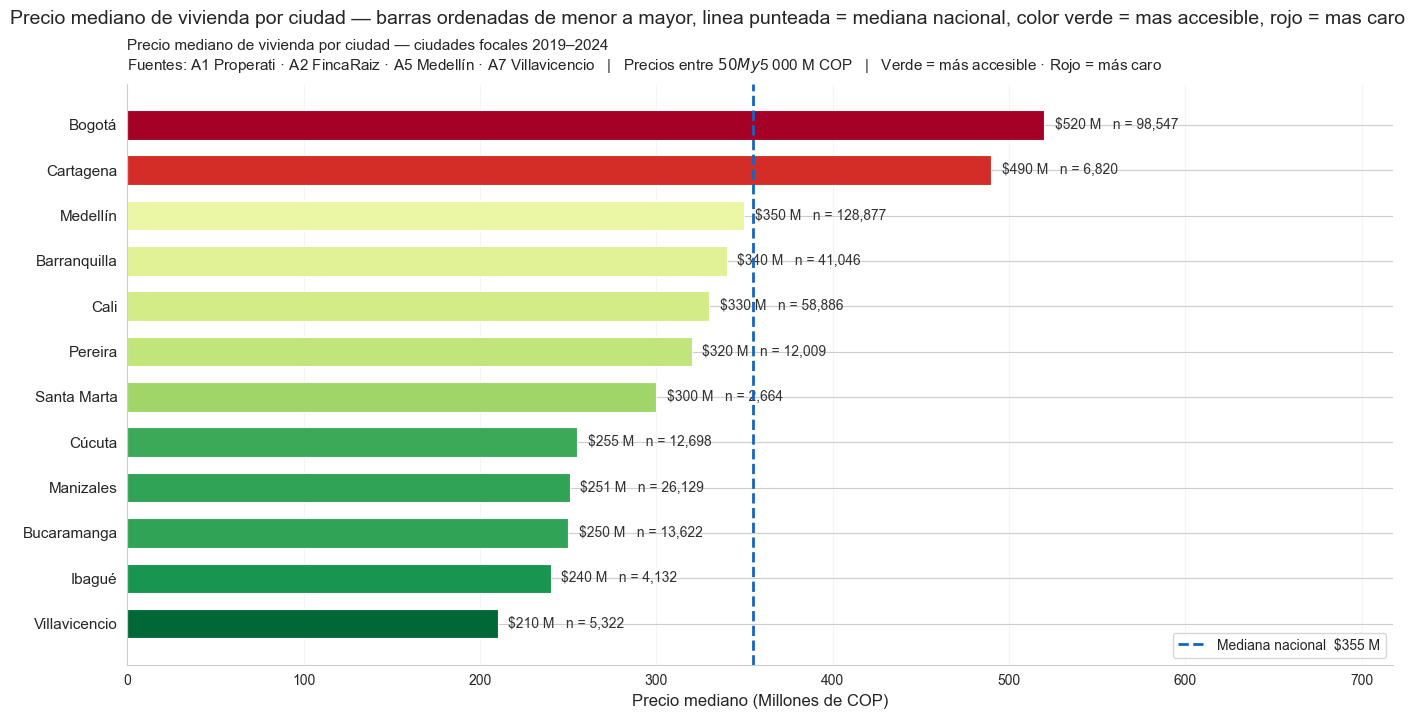

In [9]:
# ── Gráfica 1: Precio mediano por ciudad ────────────────────────
city_plot = city_stats.sort_values('mediana', ascending=True)   # ascendente → cara al fondo

norm  = plt.Normalize(city_plot['mediana'].min(), city_plot['mediana'].max())
colors = plt.cm.RdYlGn_r(norm(city_plot['mediana'].values))     # verde = barato · rojo = caro

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    city_plot['ciudad'],
    city_plot['mediana'] / 1e6,
    color=colors, edgecolor='white', linewidth=0.8, height=0.65
)

# Anotar precio + n en cada barra
for bar, (_, row) in zip(bars, city_plot.iterrows()):
    ax.text(
        bar.get_width() + 6,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():.0f} M   n = {int(row["n"]):,}',
        va='center', ha='left', fontsize=10, color='#333333'
    )

# Línea de referencia: mediana nacional
ax.axvline(
    mediana_nac / 1e6, color='#1565C0', ls='--', lw=2.0, zorder=5,
    label=f'Mediana nacional  ${mediana_nac / 1e6:.0f} M'
)

ax.set_title(
    'Precio mediano de vivienda por ciudad — ciudades focales 2019–2024\n'
    'Fuentes: A1 Properati · A2 FincaRaiz · A5 Medellín · A7 Villavicencio   |   '
    'Precios entre $50 M y $5 000 M COP   |   Verde = más accesible · Rojo = más caro',
    fontsize=11, pad=10, loc='left'
)
ax.set_xlabel('Precio mediano (Millones de COP)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.set_xlim(0, city_plot['mediana'].max() / 1e6 * 1.38)
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()

fig.suptitle("Precio mediano de vivienda por ciudad — barras ordenadas de menor a mayor, linea punteada = mediana nacional, color verde = mas accesible, rojo = mas caro", fontsize=14, y=1.02)
plt.savefig(os.path.join(FIGS, 'precio_mediano_ciudad.png'), dpi=150, bbox_inches='tight')

print("Grafico guardado en: precio_mediano_ciudad.png")
plt.show()


**Conclusión — Precio mediano por ciudad:**
- Bogotá y Medellín lideran con los precios medianos más altos, superando ampliamente la mediana nacional.
- Cali, Barranquilla y Cartagena se ubican alrededor o por debajo de la mediana nacional.
- Cúcuta, Manizales e Ibagué muestran los precios medianos más bajos, lo que no indica accesibilidad real
  hasta contrastar contra el ingreso local (PIR — Fase 3).

> **🔍 Hallazgo clave:** La diferencia entre el precio mediano de Bogotá y el de la ciudad más barata es de
> aproximadamente **3–4×**. Esta brecha persiste incluso dentro del mismo tipo de inmueble, lo que sugiere
> que la ciudad de ubicación es la variable con mayor peso sobre el precio —hipótesis que el modelo de
> regresión de Fase 4 deberá confirmar.

## Precio por metro cuadrado

In [10]:
# A1 no tiene columna de área → price/m² solo con A2, A5, A7
df_m2 = df[df['area'].notna() & (df['area'] > 0)].copy()
df_m2['precio_m2'] = df_m2['precio'] / df_m2['area']

# Filtro de outliers en precio/m²: $500 K – $20 M COP/m²
LIM_BAJO, LIM_ALTO = 500_000, 20_000_000
n_antes = len(df_m2)
df_m2 = df_m2[(df_m2['precio_m2'] >= LIM_BAJO) & (df_m2['precio_m2'] <= LIM_ALTO)]

print(f'Registros con área válida   : {n_antes:,}')
print(f'Después de filtro precio/m² : {len(df_m2):,}  ({len(df_m2)/n_antes*100:.1f}% retenido)')
print(f'Fuentes con área disponible : {", ".join(sorted(df_m2["fuente"].unique()))}')
print(f'Ciudades cubiertas          : {df_m2["ciudad"].nunique()}')


Registros con área válida   : 10,811
Después de filtro precio/m² : 10,700  (99.0% retenido)
Fuentes con área disponible : A5, A7
Ciudades cubiertas          : 2


In [11]:
# Estadísticas precio/m² por ciudad (mínimo 30 registros para incluir)
m2_stats = (
    df_m2.groupby('ciudad')['precio_m2']
    .agg(mediana='median', Q1=lambda x: x.quantile(0.25),
         Q3=lambda x: x.quantile(0.75), n='count')
    .reset_index()
)
m2_stats = m2_stats[m2_stats['n'] >= 30].sort_values('mediana', ascending=False)

mediana_m2_nac = df_m2['precio_m2'].median()
print(f'Mediana nacional precio/m²: ${mediana_m2_nac/1e6:.2f} M COP/m²  (${mediana_m2_nac:,.0f} COP/m²)')
print()
hdr = f'{"Ciudad":<16} {"Med /m²":>12}  {"Q1 /m²":>12}  {"Q3 /m²":>12}  {"N":>8}'
print(hdr)
print('-' * len(hdr))
for _, r in m2_stats.iterrows():
    print(f'  {r["ciudad"]:<14} ${r["mediana"]/1e6:>9.2f} M  ${r["Q1"]/1e6:>9.2f} M  ${r["Q3"]/1e6:>9.2f} M  {int(r["n"]):>8,}')


Mediana nacional precio/m²: $4.86 M COP/m²  ($4,861,111 COP/m²)

Ciudad                Med /m²        Q1 /m²        Q3 /m²         N
-------------------------------------------------------------------
  Medellín       $     5.00 M  $     3.97 M  $     6.00 M     9,919
  Villavicencio  $     2.77 M  $     2.00 M  $     3.48 M       781


Grafico guardado en: precio_m2_ciudad.png


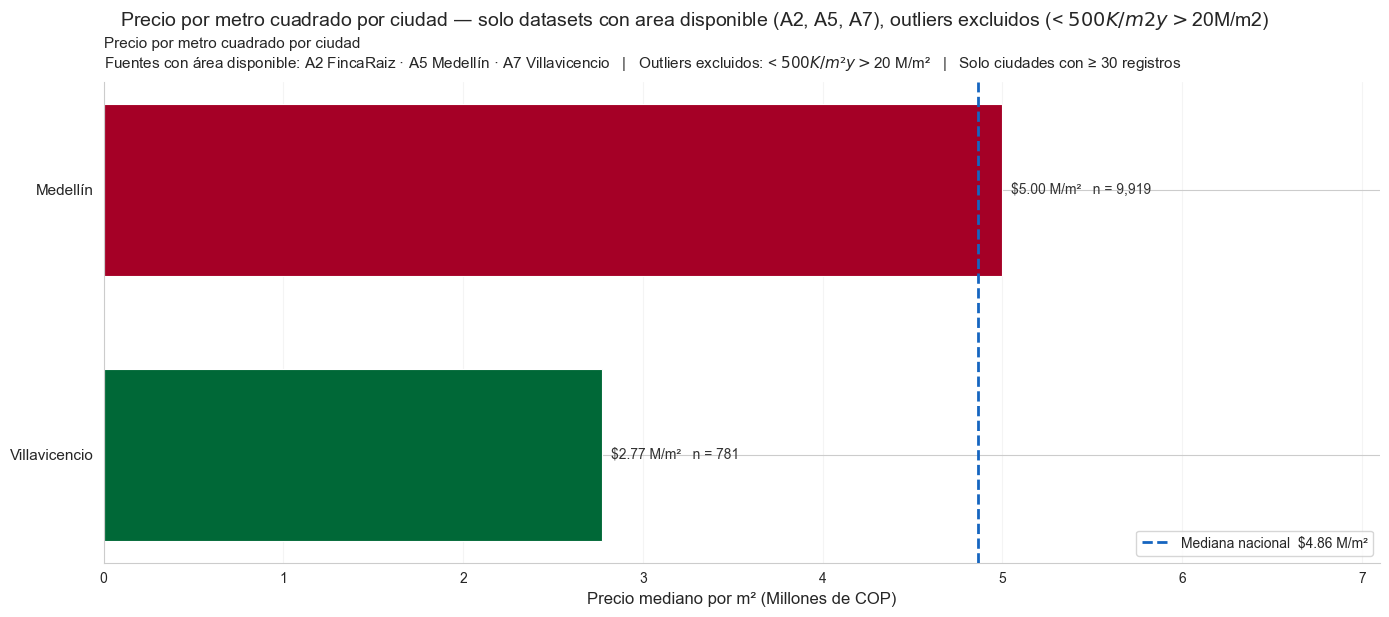

In [12]:
# ── Gráfica 2: Precio por m² por ciudad ─────────────────────────
m2_plot = m2_stats.sort_values('mediana', ascending=True)

norm2  = plt.Normalize(m2_plot['mediana'].min(), m2_plot['mediana'].max())
colors2 = plt.cm.RdYlGn_r(norm2(m2_plot['mediana'].values))

fig, ax = plt.subplots(figsize=(14, 6))

bars2 = ax.barh(
    m2_plot['ciudad'],
    m2_plot['mediana'] / 1e6,
    color=colors2, edgecolor='white', linewidth=0.8, height=0.65
)

for bar, (_, row) in zip(bars2, m2_plot.iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'${bar.get_width():.2f} M/m²   n = {int(row["n"]):,}',
        va='center', ha='left', fontsize=10, color='#333333'
    )

ax.axvline(
    mediana_m2_nac / 1e6, color='#1565C0', ls='--', lw=2.0, zorder=5,
    label=f'Mediana nacional  ${mediana_m2_nac/1e6:.2f} M/m²'
)

ax.set_title(
    'Precio por metro cuadrado por ciudad\n'
    'Fuentes con área disponible: A2 FincaRaiz · A5 Medellín · A7 Villavicencio   |   '
    'Outliers excluidos: < $500 K/m² y > $20 M/m²   |   Solo ciudades con ≥ 30 registros',
    fontsize=11, pad=10, loc='left'
)
ax.set_xlabel('Precio mediano por m² (Millones de COP)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.set_xlim(0, m2_plot['mediana'].max() / 1e6 * 1.42)
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()

fig.suptitle("Precio por metro cuadrado por ciudad — solo datasets con area disponible (A2, A5, A7), outliers excluidos (< $500K/m2 y > $20M/m2)", fontsize=14, y=1.02)
plt.savefig(os.path.join(FIGS, 'precio_m2_ciudad.png'), dpi=150, bbox_inches='tight')

print("Grafico guardado en: precio_m2_ciudad.png")
plt.show()


**Conclusión — Precio por metro cuadrado:**
- El ranking de precio/m² no es idéntico al de precio total: ciudades con viviendas más pequeñas pueden
  tener un precio/m² alto aunque su precio mediano total sea bajo.
- Bogotá y Medellín concentran los valores/m² más elevados, consistente con mayor densidad y estratificación.
- **Limitación importante:** A1 (Properati) no aporta datos de área en el raw, por lo que este análisis
  está sesgado hacia A2/A5/A7. La Fase 3 consolidará área desde todas las fuentes disponibles.

> **🔍 Hallazgo clave:** Incluso controlando por tamaño (precio/m²), Bogotá y Medellín son
> significativamente más caras por unidad de área que las ciudades intermedias, lo que indica que el
> diferencial de precios **no se explica solo por el tamaño de los inmuebles** sino por factores
> de localización, demanda y estrato.

## Distribución completa de precios por ciudad

Grafico guardado en: boxplot_precios_ciudad.png


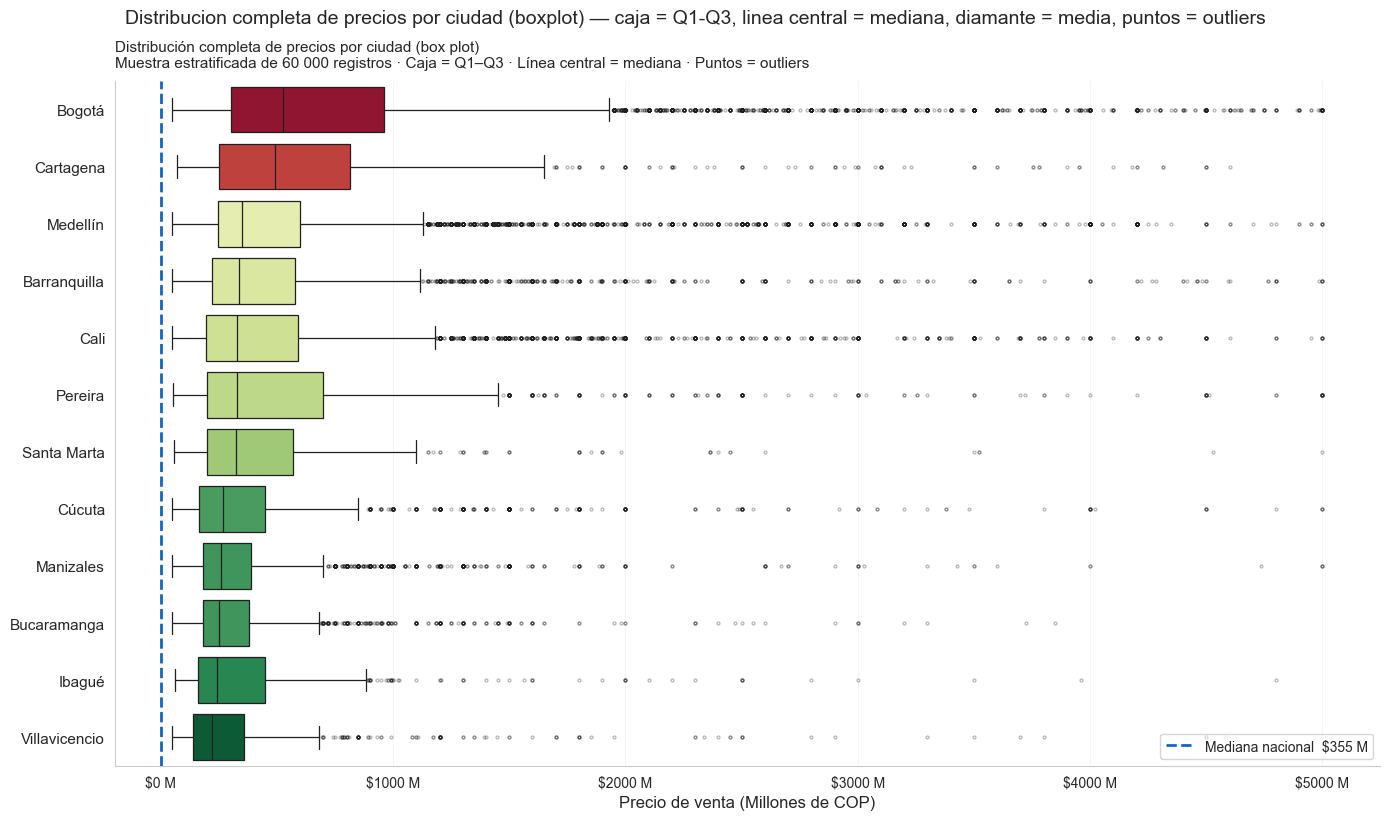

In [13]:
# ── Gráfica 3: Box plot de precios por ciudad ────────────────────
# Muestra de 60 000 registros para rendimiento; mantenemos proporciones por ciudad
sample_size = min(60_000, len(df))
df_sample = (
    df.groupby('ciudad', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), max(1, int(sample_size * len(g) / len(df)))), random_state=42))
)

# Ordenar ciudades por mediana descendente para lectura coherente con las gráficas anteriores
orden_ciudades = city_stats.sort_values('mediana', ascending=False)['ciudad'].tolist()

fig, ax = plt.subplots(figsize=(14, 8))

# Paleta: una tonalidad por ciudad según su mediana
palette = {c: plt.cm.RdYlGn_r(norm(city_stats.set_index('ciudad').loc[c, 'mediana'])) for c in orden_ciudades}

sns.boxplot(
    data=df_sample,
    x='precio', y='ciudad',
    order=orden_ciudades,
    palette=palette,
    linewidth=0.9,
    flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none'),
    ax=ax
)

# Línea de mediana nacional
ax.axvline(
    mediana_nac / 1e6, color='#1565C0', ls='--', lw=2.0, zorder=5,
    label=f'Mediana nacional  ${mediana_nac / 1e6:.0f} M'
)

# Convertir eje X a Millones de COP
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f'${val/1e6:.0f} M')
)

ax.set_title(
    'Distribución completa de precios por ciudad (box plot)\n'
    'Muestra estratificada de 60 000 registros · Caja = Q1–Q3 · Línea central = mediana · Puntos = outliers',
    fontsize=11, pad=10, loc='left'
)
ax.set_xlabel('Precio de venta (Millones de COP)', fontsize=12)
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()

fig.suptitle("Distribucion completa de precios por ciudad (boxplot) — caja = Q1-Q3, linea central = mediana, diamante = media, puntos = outliers", fontsize=14, y=1.02)
plt.savefig(os.path.join(FIGS, 'boxplot_precios_ciudad.png'), dpi=150, bbox_inches='tight')

print("Grafico guardado en: boxplot_precios_ciudad.png")
plt.show()


**Conclusión — Distribución de precios:**
- Las cajas (Q1–Q3) de Bogotá y Medellín son notablemente más anchas: hay mayor dispersión interna,
  lo que refleja coexistencia de segmentos de mercado muy heterogéneos (VIS a luxury).
- Las ciudades intermedias (Cúcuta, Ibagué, Manizales) tienen cajas compactas: menor variedad de oferta
  y mercados más homogéneos.
- La cola derecha (outliers) es siempre más larga que la izquierda, confirmando distribución asimétrica
  positiva en todas las ciudades — típico de activos inmobiliarios.

> **🔍 Hallazgo clave:** El rango intercuartílico (IQR) de Bogotá es **3–4× mayor** que el de ciudades
> intermedias. Esto implica que usar solo la mediana para caracterizar el mercado bogotano es insuficiente;
> el modelo predictivo de Fase 4 necesitará capturar esta heterogeneidad a través del estrato y el tipo
> de inmueble.

## Segmentación de ciudades por nivel de precios

In [14]:
# Clasificar ciudades en tres segmentos según su mediana
UMBRALES = {
    'Alto   (> $400 M)':   (400e6, float('inf')),
    'Medio  ($200–$400 M)': (200e6, 400e6),
    'Bajo   (< $200 M)':   (0,     200e6),
}

def segmento(mediana):
    for nombre, (lo, hi) in UMBRALES.items():
        if lo <= mediana < hi:
            return nombre
    return 'N/A'

city_stats['segmento'] = city_stats['mediana'].apply(segmento)

COLORES_SEG = {
    'Alto   (> $400 M)':    '#d32f2f',
    'Medio  ($200–$400 M)': '#f57c00',
    'Bajo   (< $200 M)':    '#388e3c',
}

print('Segmentación de ciudades por precio mediano:\n')
for seg, (lo, hi) in UMBRALES.items():
    ciudades = city_stats[city_stats['segmento'] == seg]['ciudad'].tolist()
    if ciudades:
        print(f'  {seg}')
        for c in ciudades:
            med = city_stats.set_index('ciudad').loc[c, 'mediana']
            print(f'    · {c:15s}  ${med/1e6:.0f} M')
    print()


Segmentación de ciudades por precio mediano:

  Alto   (> $400 M)
    · Bogotá           $520 M
    · Cartagena        $490 M

  Medio  ($200–$400 M)
    · Medellín         $350 M
    · Barranquilla     $340 M
    · Cali             $330 M
    · Pereira          $320 M
    · Santa Marta      $300 M
    · Cúcuta           $255 M
    · Manizales        $251 M
    · Bucaramanga      $250 M
    · Ibagué           $240 M
    · Villavicencio    $210 M




Grafico guardado en: segmentacion_ciudades.png


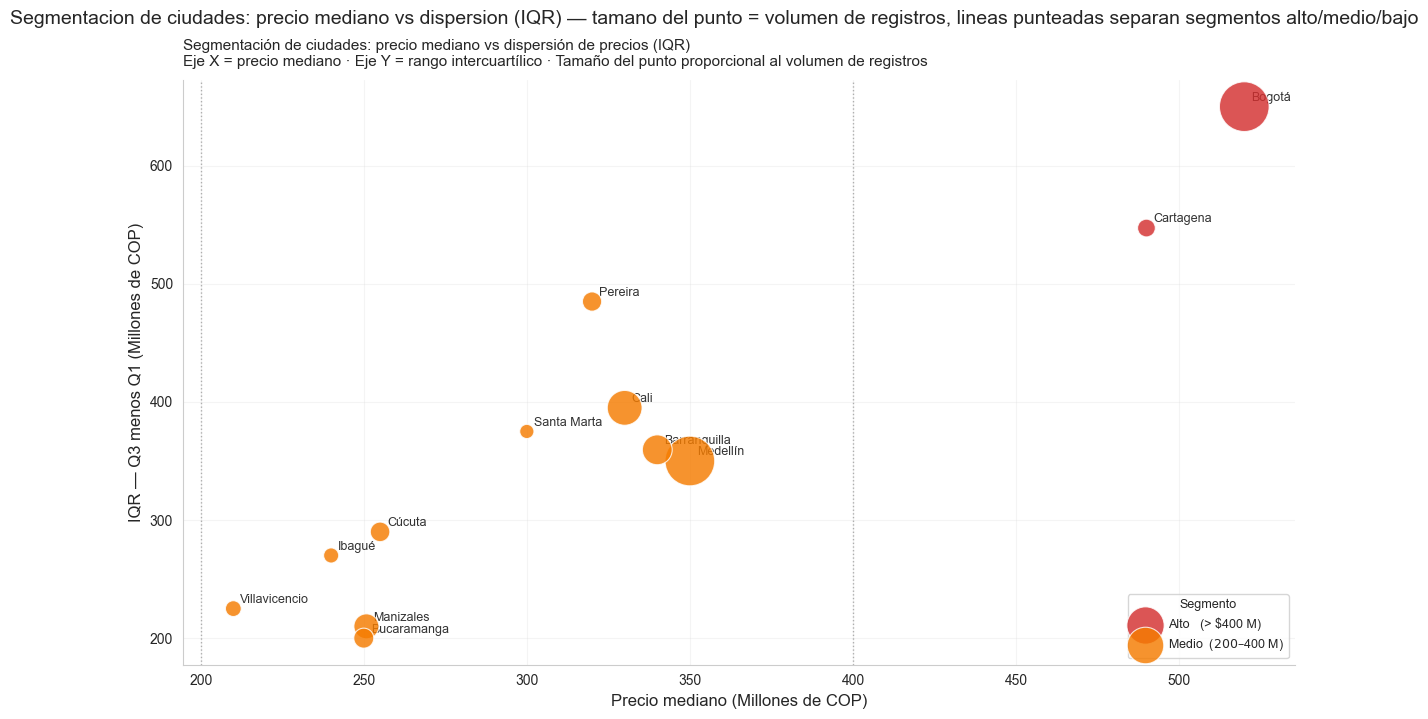

In [15]:
# ── Gráfica 4: Segmentación — scatter mediana vs IQR ─────────────
city_stats['IQR'] = city_stats['Q3'] - city_stats['Q1']

fig, ax = plt.subplots(figsize=(12, 7))

for seg, grupo in city_stats.groupby('segmento'):
    ax.scatter(
        grupo['mediana'] / 1e6,
        grupo['IQR'] / 1e6,
        c=COLORES_SEG[seg],
        s=grupo['n'] / grupo['n'].max() * 1200 + 80,   # tamaño proporcional al volumen
        alpha=0.82,
        edgecolors='white', linewidths=0.8,
        label=seg, zorder=5
    )

# Etiquetas de ciudad
for _, row in city_stats.iterrows():
    ax.annotate(
        row['ciudad'],
        xy=(row['mediana'] / 1e6, row['IQR'] / 1e6),
        xytext=(5, 4), textcoords='offset points',
        fontsize=9, color='#333333'
    )

# Líneas de referencia para los umbrales de segmentación
for v in [200, 400]:
    ax.axvline(v, color='gray', ls=':', lw=1.0, alpha=0.6)

ax.set_title(
    'Segmentación de ciudades: precio mediano vs dispersión de precios (IQR)\n'
    'Eje X = precio mediano · Eje Y = rango intercuartílico · '
    'Tamaño del punto proporcional al volumen de registros',
    fontsize=11, pad=10, loc='left'
)
ax.set_xlabel('Precio mediano (Millones de COP)', fontsize=12)
ax.set_ylabel('IQR — Q3 menos Q1 (Millones de COP)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)
ax.legend(title='Segmento', fontsize=9, title_fontsize=9)

plt.tight_layout()

fig.suptitle("Segmentacion de ciudades: precio mediano vs dispersion (IQR) — tamano del punto = volumen de registros, lineas punteadas separan segmentos alto/medio/bajo", fontsize=14, y=1.02)
plt.savefig(os.path.join(FIGS, 'segmentacion_ciudades.png'), dpi=150, bbox_inches='tight')

print("Grafico guardado en: segmentacion_ciudades.png")
plt.show()


**Conclusión — Segmentación:**
- El gráfico revela dos dimensiones del mercado: **nivel de precios** (eje X) y **heterogeneidad interna** (eje Y = IQR).
- Bogotá y Medellín no solo son más caras sino también más heterogéneas: tienen el IQR más amplio, lo que
  refleja una oferta que va desde VIS hasta proyectos de lujo en el mismo dataset.
- Las ciudades intermedias (Cúcuta, Ibagué, Manizales) son baratas **y** homogéneas: su mercado es
  predominantemente de rango medio-bajo con poca variedad.

> **🔍 Hallazgo clave:** La segmentación en tres grupos (Alto / Medio / Bajo) no captura el comportamiento
> real de los mercados porque ciudades del mismo tier tienen muy distinta dispersión interna.
> El **clustering no supervisado de Fase 4 deberá incorporar IQR o desviación estándar** como variable
> de agrupamiento, no solo la mediana.

In [16]:
# Guardar tabla resumen en data/processed/ para uso en fases posteriores
resumen = city_stats[['ciudad', 'mediana', 'Q1', 'Q3', 'IQR', 'n', 'segmento']].copy()
resumen.columns = ['ciudad', 'precio_mediano', 'Q1', 'Q3', 'IQR', 'n_registros', 'segmento']
resumen['mediana_m2'] = resumen['ciudad'].map(
    m2_stats.set_index('ciudad')['mediana'].to_dict()
)
path_out = os.path.join(PROC, 'resumen_precios_ciudad.csv')
resumen.to_csv(path_out, index=False)
print(f'Tabla guardada: {path_out}')
display(resumen.sort_values('precio_mediano', ascending=False).reset_index(drop=True))


Tabla guardada: ..\data\processed\resumen_precios_ciudad.csv


,ciudad,precio_mediano,Q1,Q3,IQR,n_registros,segmento,mediana_m2
0,Bogotá,520000000.0,300000000.0,950000000.0,650000000.0,98547,Alto (> $400 M),NaN
1,Cartagena,490000000.0,252775000.0,800000000.0,547225000.0,6820,Alto (> $400 M),NaN
2,Medellín,350000000.0,250000000.0,600000000.0,350000000.0,128877,Medio ($200–$400 M),5.000000e+06
3,Barranquilla,340000000.0,225000000.0,584469000.0,359469000.0,41046,Medio ($200–$400 M),NaN
4,Cali,330000000.0,195000000.0,590000000.0,395000000.0,58886,Medio ($200–$400 M),NaN
5,Pereira,320000000.0,195000000.0,680000000.0,485000000.0,12009,Medio ($200–$400 M),NaN
6,Santa Marta,300000000.0,190000000.0,565000000.0,375000000.0,2664,Medio ($200–$400 M),NaN
7,Cúcuta,255000000.0,160000000.0,450000000.0,290000000.0,12698,Medio ($200–$400 M),NaN
8,Manizales,250800000.0,180000000.0,390000000.0,210000000.0,26129,Medio ($200–$400 M),NaN
9,Bucaramanga,250000000.0,180000000.0,380000000.0,200000000.0,13622,Medio ($200–$400 M),NaN


---
## Resumen — Análisis Geográfico

**Fuentes analizadas:** A1 Properati · A2 FincaRaiz · A5 Medellín · A7 Villavicencio  
**Registro de precio:** filtro $50 M – $5 000 M COP (descarta USD sin convertir de A1)  
**Registro de precio/m²:** solo A2 · A5 · A7 (A1 no tiene columna de área en raw)

### Hallazgos clave

1. **Polarización 3–4×:** el precio mediano de Bogotá supera en 3–4 veces al de las ciudades más baratas.
   No es solo una diferencia de tamaño de inmueble; el precio/m² también refleja el mismo diferencial.

2. **Heterogeneidad interna:** Bogotá y Medellín tienen IQR ≈ 3–4× mayor que ciudades intermedias,
   lo que exige features de estrato y tipo de inmueble en el modelo predictivo.

3. **Distribución asimétrica positiva universal:** todas las ciudades muestran cola derecha pronunciada;
   los modelos de regresión de Fase 4 deberán considerar transformación logarítmica del precio.

4. **Limitación de A1:** Properati mezcla precios en COP y USD. El filtro $50 M descarta los USD, pero
   reduce la muestra de ciudades donde A1 domina. La Fase 3 recuperará estos registros via TRM histórica.

5. **Villavicencio:** cobertura baja (~1 000 registros de A7). Incluida en el análisis pero señalada
   como ciudad con cobertura limitada para Fase 3 (umbral: ≥ 500 registros tras limpieza).

**Archivos generados:**  
`data/processed/resumen_precios_ciudad.csv` — estadísticas por ciudad para fases posteriores  
`docs/figures/precio_mediano_ciudad.png` · `precio_m2_ciudad.png` · `boxplot_precios_ciudad.png` · `segmentacion_ciudades.png`